In [ ]:
import nltk
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("comments.csv")

allPositiveComments = df[df['sentiment'] == 'positive']['text'].tolist()
allNegativeComments = df[df['sentiment'] == 'negative']['text'].tolist()

comments = allPositiveComments + allNegativeComments
labels = np.append(np.ones(len(allPositiveComments)), np.zeros(len(allNegativeComments)))

print(f"Total comments: {len(comments)} (Positive: {len(allPositiveComments)}, Negative: {len(allNegativeComments)})")

Total comments: 2402 (Positive: 1201, Negative: 1201)


[nltk_data] Downloading package stopwords to /Users/elian/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
def processComment(comment):

  # removes links, usernames, and hashtags
  comment = re.sub(r'https?://[^\s\n\r]+', '', comment)
  comment = re.sub(r'@[\w]+', '', comment)
  comment = re.sub(r'#', '', comment)

  tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
  tokens = tokenizer.tokenize(comment)

  emoticons = {":)", ":(", ":D", ";D", ":-)", ":-(", "<3", ":/"}

  # removes stop words, punctuation (except emoticons)
  stopwordsEnglish = stopwords.words('english')
  words = []

  for word in tokens:
    if word in emoticons:
      words.append(word)
    elif word not in stopwordsEnglish and word.isalpha():
      words.append(word)

  stemmer = PorterStemmer()
  processedWords = []
  for word in words:
    if word in emoticons:
      processedWords.append(word)
    else:
      processedWords.append(stemmer.stem(word))

  return processedWords

In [6]:
sampleComment = allPositiveComments[17]
processedComment = processComment(sampleComment)

print(sampleComment)
print(processedComment)

sampleComment = allNegativeComments[17]
processedComment = processComment(sampleComment)

print(sampleComment)
print(processedComment)

This is the best cat video 😂 ❤
['best', 'cat', 'video']
Something very traumatic has happened at the dog park
['someth', 'traumat', 'happen', 'dog', 'park']


In [7]:
def buildFrequencyDictionary(comments, labels):
    frequencyDictionary = {}

    for comment, label in zip(comments, labels):
        words = processComment(comment)
        for word in words:
            pair = (word, int(label))
            if pair in frequencyDictionary:
                frequencyDictionary[pair] += 1
            else: 
                frequencyDictionary[pair] = 1

    return frequencyDictionary

frequencyDictionary = buildFrequencyDictionary(comments, labels)
print(frequencyDictionary)

{('cat', 1): 188, ('clean', 1): 2, ('anim', 1): 64, ('smart', 1): 30, ('love', 1): 327, ('take', 1): 30, ('care', 1): 21, ('wonder', 1): 17, ('pet', 1): 20, ('companion', 1): 2, ('slop', 1): 4, ('pretti', 1): 28, ('funni', 1): 68, ('wow', 1): 30, ('thank', 1): 37, ('share', 1): 15, ('full', 1): 8, ('video', 1): 55, ('groundhog', 1): 3, ('clever', 1): 8, ('sip', 1): 1, ('water', 1): 5, ('polit', 1): 2, ('slowli', 1): 3, ('weasel', 1): 1, ('eat', 1): 8, ('food', 1): 7, ('ran', 1): 4, ('away', 1): 13, ('nice', 1): 27, ('mouth', 1): 4, ('beauti', 1): 51, ('show', 1): 10, ('respect', 1): 5, ('side', 1): 7, ('american', 1): 5, ('pitbul', 1): 5, ('bluenos', 1): 1, ('amaz', 1): 46, ('snoopi', 1): 1, ('big', 1): 10, ('sweetheart', 1): 3, ('play', 1): 15, ('obsess', 1): 1, ('carrot', 1): 1, ('never', 1): 26, ('aggress', 1): 2, ('gentl', 1): 2, ('pup', 1): 9, ('mani', 1): 12, ('memori', 1): 4, ('plan', 1): 4, ('get', 1): 70, ('portrait', 1): 1, ('paint', 1): 1, ('hang', 1): 5, ('famili', 1): 20, 

notes to self; this function returns a dictionary with key pairs of words and their sentiments (presented as tuples), as well as the amount of times that the word appeared in comments with that label as a value
* if the word "good" appears in both positive and negative comments, the dictionary would contain them both as separate entries
* using the dictionary allows you to determine if a new word is more associated with positive or negative sentiments by retrieving information

In [8]:
word1 = "smile"
word2 = "frown"

posCountW1 = frequencyDictionary.get((word1, 1), 0)
negCountW1 = frequencyDictionary.get((word1, 0), 0)
posCountW2 = frequencyDictionary.get((word2, 1), 0)
negCountW2 = frequencyDictionary.get((word2, 0), 0)

print(f'{word1} appears {posCountW1} times in positive comments and {negCountW1} times in negative comments.')
print(f'{word2} appears {posCountW2} times in positive comments and {negCountW2} times in negative comments.')

word3 = "happi"
word4 = "sad"

posCountW3 = frequencyDictionary.get((word3, 1), 0)
negCountW3 = frequencyDictionary.get((word3, 0), 0)
posCountW4 = frequencyDictionary.get((word4, 1), 0)
negCountW4 = frequencyDictionary.get((word4, 0), 0)

print(f'{word3} appears {posCountW3} times in positive comments and {negCountW3} times in negative comments.')
print(f'{word4} appears {posCountW4} times in positive comments and {negCountW4} times in negative comments.')

smile appears 16 times in positive comments and 2 times in negative comments.
frown appears 0 times in positive comments and 0 times in negative comments.
happi appears 23 times in positive comments and 5 times in negative comments.
sad appears 1 times in positive comments and 44 times in negative comments.


[['happi', 23, 5], ['sad', 1, 44], ['love', 327, 14], ['hate', 6, 69], [':)', 7, 1], [':(', 0, 8], ['best', 108, 5], ['worst', 0, 28]]


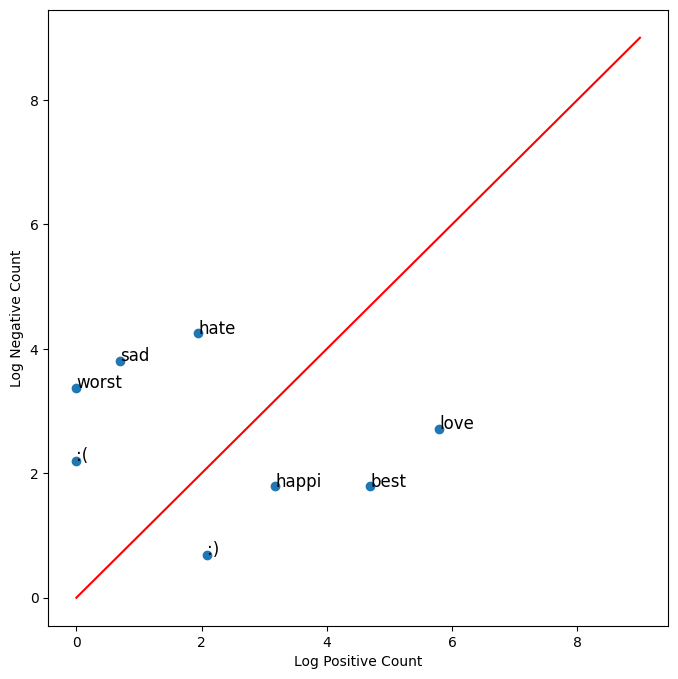

In [9]:
visualizeWords = ['happi', 'sad', 'love', 'hate', ':)', ':(', 'best', 'worst']

data = []
for word in visualizeWords:
    posCount = frequencyDictionary.get((word, 1), 0)
    negCount = frequencyDictionary.get((word, 0), 0)
    data.append([word, posCount, negCount])
print(data)

fig, ax = plt.subplots(figsize = (8, 8))
x = []
y = []
for wordVector in data:
    x.append(np.log(wordVector[1] + 1))
    y.append(np.log(wordVector[2] + 1))
ax.scatter(x, y)

for i in range(0, len(data)):
    ax.annotate(data[i][0], (x[i], y[i]), fontsize = 12)

ax.plot([0, 9], [0, 9], color = 'red')
plt.xlabel("Log Positive Count")
plt.ylabel("Log Negative Count")
plt.show()

note to self; because of the cleaning and preprocessing function from earlier, a lot of words have been stripped down to their core meanings: this is visible with "happi" appearing on the graph
* this is due to the words being reduced into their basic forms, meaning words like "happy", "happiness", and "happier" all count as "happi"

if a word appears exactly on the red diagonal, that indicates it appeared the same amount of times in both the positive and negative comments. the algorith sees the word as being more neutral, though that might just be because it's difficult to classify

[['smile', 16, 2], ['cat', 188, 440], ['dog', 168, 155], ['laugh', 18, 13], ['cri', 3, 31]]


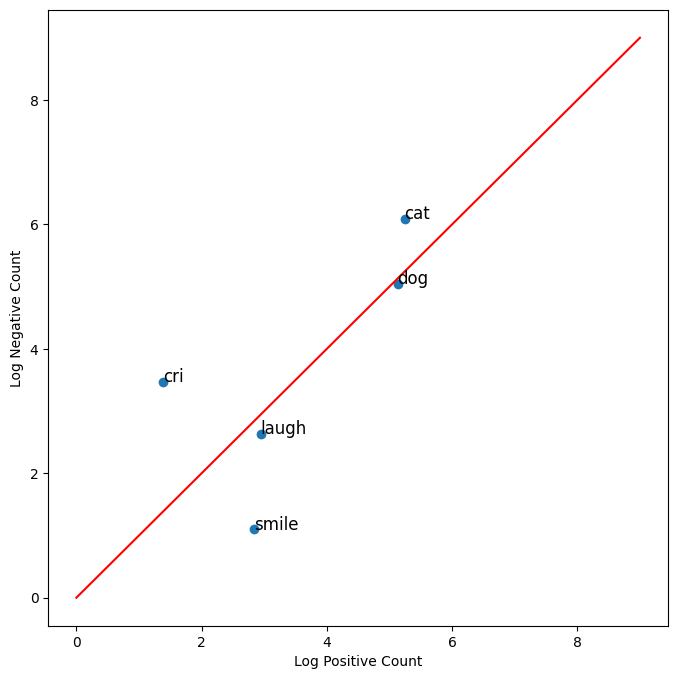

In [10]:
visualizeWords = ['smile', 'cat', 'dog', 'laugh', 'cri']

data = []
for word in visualizeWords:
    posCount = frequencyDictionary.get((word, 1), 0)
    negCount = frequencyDictionary.get((word, 0), 0)
    data.append([word, posCount, negCount])
print(data)

fig, ax = plt.subplots(figsize = (8, 8))
x = []
y = []
for wordVector in data:
    x.append(np.log(wordVector[1] + 1))
    y.append(np.log(wordVector[2]+ 1))
ax.scatter(x, y)

for i in range(0, len(data)):
    ax.annotate(data[i][0], (x[i], y[i]), fontsize = 12)

ax.plot([0, 9], [0, 9], color = "red")
plt.xlabel("Log Positive Count")
plt.ylabel("Log Negative Count")
plt.show()

In [17]:
def extractFeatures(comment, frequencyDictionary):
    words = processComment(comment)
    posSum, negSum = 0, 0

    for word in words:
        posSum += frequencyDictionary.get((word, 1), 0)
        negSum += frequencyDictionary.get((word, 0), 0)

    return np.array([1, posSum, negSum])

note to self; this function returns a numpy array with the bias term (which should always be 1), the sentence's positive word frequency, an the sentence's negative word frequency
* can usually be read as [1, pos > neg, neg < pos] or [1, pos < neg, neg > pos] depending on what sentiment the sentence holds
* using word frequency for snetiment analysis skips over word order and context, making it more difficult to pick up on common literary devices like irony and sarcasm

In [18]:
commentFeatures = []

for comment in comments:
    vector = extractFeatures(comment, frequencyDictionary)
    commentFeatures.append(vector)

commentFeatures = np.array(commentFeatures)
print(commentFeatures.shape)

(2402, 3)


In [19]:
commentFeaturesTrain, commentFeaturesTest, labelsTrain, labelsTest = train_test_split(commentFeatures, labels, test_size = 0.05, random_state = 42)
model = LogisticRegression()
model.fit(commentFeaturesTrain, labelsTrain)

sentimentPredictions = model.predict(commentFeaturesTest)
accuracy = accuracy_score(labelsTest, sentimentPredictions)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9173553719008265


/Users/elian/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/elian/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/elian/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


In [14]:
''' 
way to test out the scores of custom, individual messages 

customMessage = 
customFeatures = extractFeatures(customMessage, frequencyDictionary)
customFeatures = customFeatures.reshape(1, -1)

prediction = model.predict(customFeatures)
probability = model.predict_proba(customFeatures)[0][1]

if prediction == 1:
    sentiment = "positive"
elif prediction == 0:
    sentiment = "negative"

print(f"Your message was classified as {sentiment} with {probability:.2f} confidence in this prediction.")
'''

' \nway to test out the scores of custom, individual messages \n\ncustomMessage = \ncustomFeatures = extractFeatures(customMessage, frequencyDictionary)\ncustomFeatures = customFeatures.reshape(1, -1)\n\nprediction = model.predict(customFeatures)\nprobability = model.predict_proba(customFeatures)[0][1]\n\nif prediction == 1:\n    sentiment = "positive"\nelif prediction == 0:\n    sentiment = "negative"\n\nprint(f"Your message was classified as {sentiment} with {probability:.2f} confidence in this prediction.")\n'